In [1]:
from datetime import datetime

from matplotlib import pyplot as plt

from py_eddy_tracker.dataset.grid import RegularGridDataset

from py_eddy_tracker.observations.observation import EddiesObservations

from glob import glob

import cartopy.crs as ccrs


# Params.:

In [2]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

In [3]:
nyear = 2023
nmonth = 11

# Functions:

In [4]:
def start_axes_map(title):
    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94], projection=ccrs.PlateCarree())

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

# Loading data:

In [5]:
from pathlib import Path as PathL

# Get the user's home directory
homedir = PathL.home()
# print(f"Home directory: {homedir}")

In [6]:
indir_duacs_nrt = str(homedir) + "/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

In [7]:
fname = "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_" + str(nyear) + str(nmonth).zfill(2) + "*_sub.nc"


In [8]:
data_paths = sorted(glob(indir_duacs_nrt + fname))

# Eddy identification:

In [9]:
outdir = "../../data/eddy-tracker_outputs/"

In [10]:
# 2 erroneous data in original files for DUACS-OI NRT. 
err_dates = {
    datetime(2023, 11, 9, 0, 0),
    datetime(2023, 11, 11, 0, 0)
}

In [11]:
for data_path in data_paths:
    g = RegularGridDataset(data_path, "longitude", "latitude")
    g.add_uv("adt")
    g.bessel_high_filter("adt", 500)
    
    date = datetime(int(data_path[-15:-11]), int(data_path[-11:-9]),
                    int(data_path[-9:-7]))
    if date in err_dates:
        continue

    a, c = g.eddy_identification("adt", "u", "v", date , 0.002, shape_error=55)
    a_name = outdir + 'a_DUACS-NRT_' + date.strftime('%Y%m%d')+'.nc'
    c_name = outdir + 'c_DUACS-NRT_' + date.strftime('%Y%m%d')+'.nc'
    a.write_file(filename = a_name)
    c.write_file(filename = c_name)
    

We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20231101_sub.nc


/opt/anaconda3/envs/venv_py-eddy-tracker_05/lib/python3.10/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20231102_sub.nc
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20231103_sub.nc
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20231104_sub.nc
We assume pixel position of grid is centered for /Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_20231105_sub.nc
We assume pixel 

# Checks:

## Checking files generated:

In [12]:
!ls ../../data/eddy-tracker_outputs/*DUACS*01.nc

../../data/eddy-tracker_outputs/a_DUACS-NRT_20230801.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20230901.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20231001.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20231101.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20231201.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240101.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240201.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240301.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240401.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240501.nc
../../data/eddy-tracker_outputs/a_DUACS-NRT_20240601.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20230801.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20230901.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20231001.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20231101.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20231201.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_20240101.nc
../../data/eddy-tracker_outputs/c_DUACS-NRT_2024

## Checking one output file (last day):

In [13]:
a_name

'../../data/eddy-tracker_outputs/a_DUACS-NRT_20231130.nc'

In [14]:
c_name

'../../data/eddy-tracker_outputs/c_DUACS-NRT_20231130.nc'

In [15]:
a = EddiesObservations.load_file(a_name)
c = EddiesObservations.load_file(c_name)

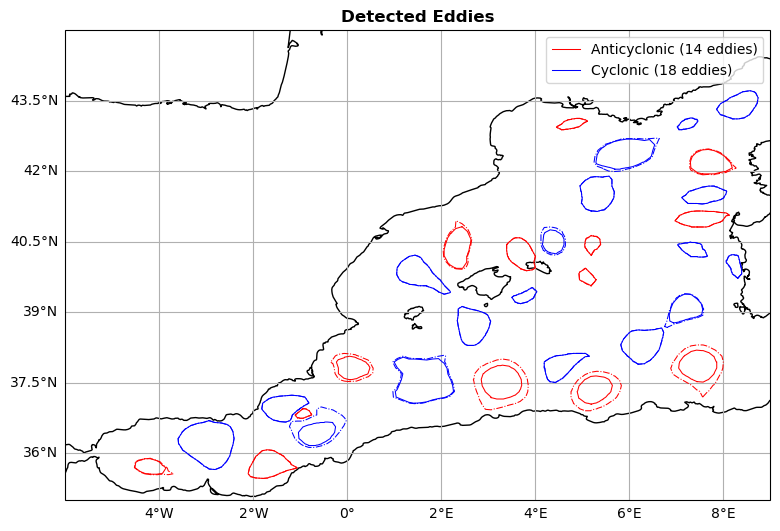

In [16]:
ax = start_axes_map("Detected Eddies")
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)
a.display(
    ax, color="r", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
          )
c.display(ax, color="b", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree()
          )
ax.legend()
update_axes(ax)

# Code references
https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html